# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age
* Fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [1]:
import os
print(os.listdir())

import pandas as pd

titanic_df = pd.read_csv('titanic_passengers.csv')

titanic_df.head(25)

['spotify-2023.csv', 'bst_boost_interprocess', 'Untitled1.ipynb', '2ND-8TH-911- VIETNAM 2.0.docx', '.localized', 'Untitled.ipynb', "Juan's AP NOTES QUIZ.docx", 'My Movie.mp4', 'Documents - Juan’s MacBook Pro', 'Fusion 360', '1.3 Data Visualization Lab.ipynb', 'Autodesk', 'SCHS.5.mp4', '1.5 Intro to Python and Pandas Lab.ipynb', 'Arduino', 'PlaybackEventStreams', 'actaruslab_f1_telemetry_2026.csv', 'Zoom', '.ipynb_checkpoints', 'titanic_passengers.csv', 'SC.2.mp4', 'sc.3.mp4', '2.3 Visualizing Relationships Between Categorical Features Lab.ipynb']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
titanic_df['Fare'].mean()

32.204207968574636

In [3]:
titanic_df['Fare'].median()

14.4542

In [4]:
titanic_df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [2]:
titanic_df['AgeCategory'] = 'Unknown'

titanic_df.loc[titanic_df['Age'] < 13, 'AgeCategory'] = 'Child'
titanic_df.loc[(titanic_df['Age'] >= 13) & (titanic_df['Age'] < 20), 'AgeCategory'] = 'Teen'
titanic_df.loc[(titanic_df['Age'] >= 20) & (titanic_df['Age'] < 60), 'AgeCategory'] = 'Adult'
titanic_df.loc[titanic_df['Age'] >= 60, 'AgeCategory'] = 'Senior'

titanic_df['FareCategory'] = 'Unknown'
titanic_df.loc[titanic_df['Fare'] < 10, 'FareCategory'] = 'Low'
titanic_df.loc[(titanic_df['Fare'] >= 10) & (titanic_df['Fare'] < 30), 'FareCategory'] = 'Medium'
titanic_df.loc[titanic_df['Fare'] >= 30, 'FareCategory'] = 'High'

titanic_df[['Age', 'AgeCategory', 'Fare', 'FareCategory']].head(10)

,Age,AgeCategory,Fare,FareCategory
0,22.0,Adult,7.2500,Low
1,38.0,Adult,71.2833,High
2,26.0,Adult,7.9250,Low
3,35.0,Adult,53.1000,High
4,35.0,Adult,8.0500,Low
5,NaN,Unknown,8.4583,Low
6,54.0,Adult,51.8625,High
7,2.0,Child,21.0750,Medium
8,27.0,Adult,11.1333,Medium
9,14.0,Teen,30.0708,High


## Quantitative Feature Categories

I categorized Age and Fare so they could be used as categorical features in the visualizations. For Age, I used child, teen, adult, and senior groups. For Fare, I used low, medium, and high categories based on the spread of the fare data. This made it easier to compare survival outcomes across groups.

In [3]:
import matplotlib.pyplot as plt

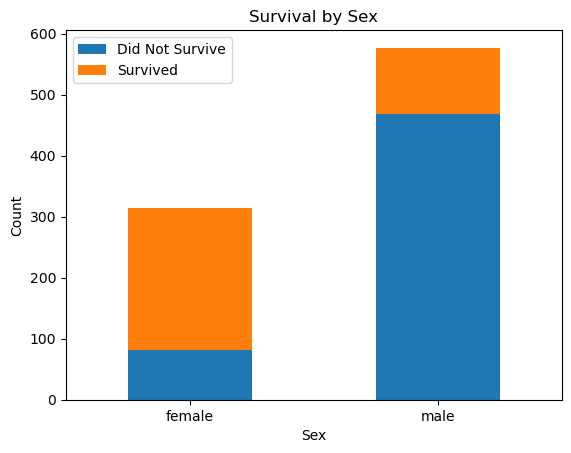

In [4]:
pd.crosstab(titanic_df['Sex'], titanic_df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

This chart shows that females had a much higher survival rate than males. Sex appears to be one of the strongest indicators of survival in the dataset.

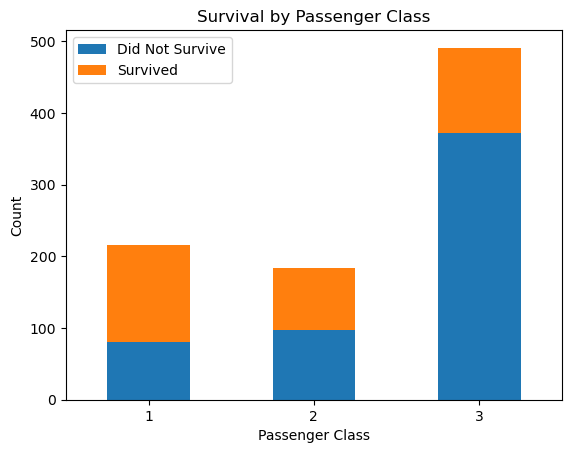

In [5]:
pd.crosstab(titanic_df['Pclass'], titanic_df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

This chart shows that first-class passengers survived at a higher rate than second- and third-class passengers. Third-class passengers had the worst survival outcomes.

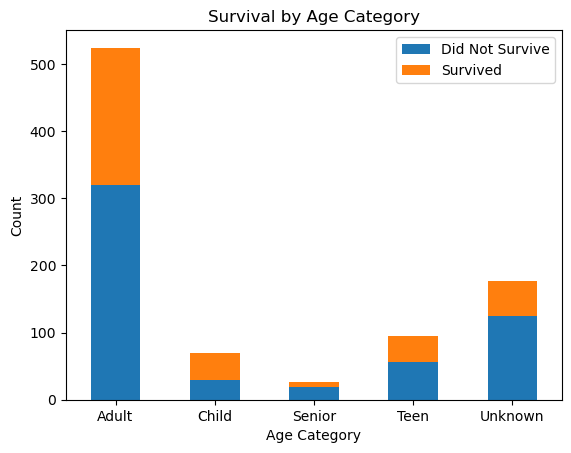

In [6]:
pd.crosstab(titanic_df['AgeCategory'], titanic_df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

This chart compares survival across age groups. Adults make up a large portion of the dataset, while children appear to have better survival outcomes than some older groups.

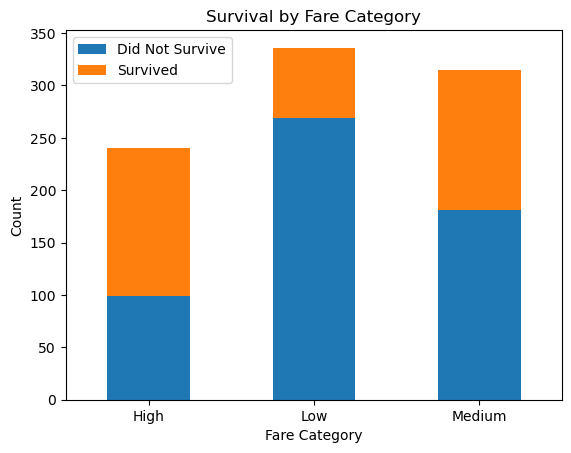

In [7]:
pd.crosstab(titanic_df['FareCategory'], titanic_df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Fare Category')
plt.xlabel('Fare Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

This chart shows that passengers in the high fare category survived more often than passengers in the low fare category. Fare appears to be related to survival, likely because it connects to passenger class and access.

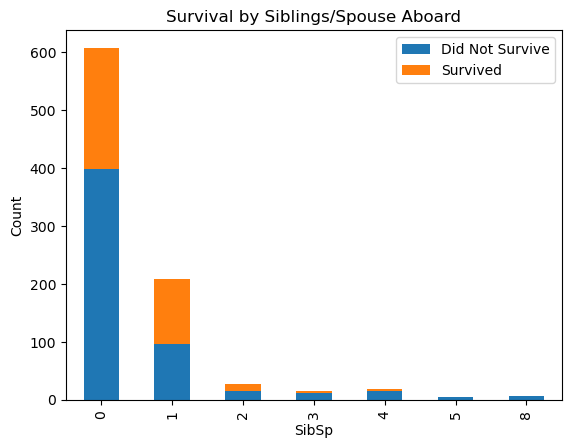

In [9]:
pd.crosstab(titanic_df['SibSp'], titanic_df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Siblings/Spouse Aboard')
plt.xlabel('SibSp')
plt.ylabel('Count')
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

This chart shows survival by the number of siblings or spouses aboard. Passengers with a small number of companions appear to have better survival outcomes than those traveling in larger groups.

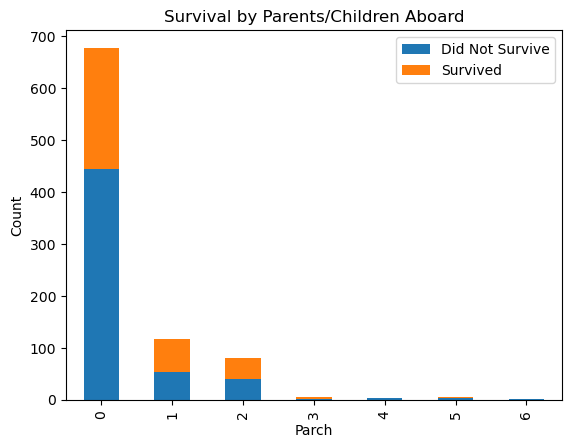

In [10]:
pd.crosstab(titanic_df['Parch'], titanic_df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Parents/Children Aboard')
plt.xlabel('Parch')
plt.ylabel('Count')
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

This chart shows survival by the number of parents or children aboard. Passengers with fewer parents or children aboard appear more common, and smaller family groupings seem easier to connect to survival than very large groups.

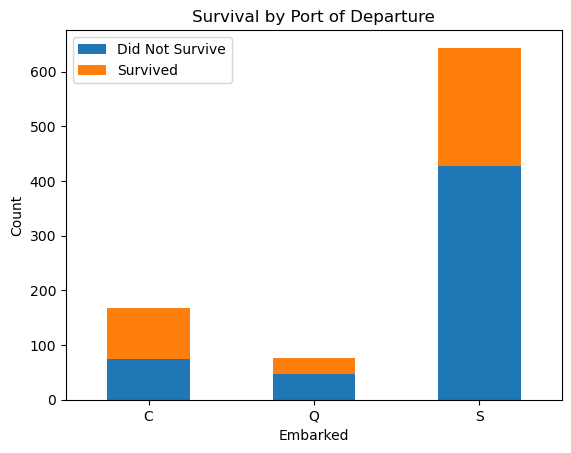

In [11]:
pd.crosstab(titanic_df['Embarked'], titanic_df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Port of Departure')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

This chart shows survival based on port of departure. Passengers who embarked at Cherbourg appear to have stronger survival outcomes than some other groups, while Southampton includes many more non-survivors.

## Most Likely to Survive Character Profile

The passenger most likely to survive was a female in first class who paid a high fare. Based on the age visualization, this passenger would most likely be a child or adult rather than an older passenger. The survival charts also suggest that traveling with a small number of companions gave better survival outcomes than traveling in a large group. Based on the embarkation chart, this passenger may have embarked at Cherbourg. Overall, the most likely survivor profile is a female first-class passenger with a high fare, a small number of travel companions, and an age category of child or adult.

## Least Likely to Survive Character Profile

The passenger least likely to survive was an adult male in third class who paid a low fare. The charts show that males had much lower survival rates than females, and third-class passengers had the poorest survival outcomes overall. Lower fares were also associated with lower survival. Based on the travel companion charts, this passenger was most likely traveling alone or with a very small group, and based on the port chart, this passenger may have embarked at Southampton. Overall, the least likely survivor profile is an adult male in third class with a low fare and few travel companions.

In [12]:
most_likely = titanic_df[
    (titanic_df['Sex'] == 'female') &
    (titanic_df['Pclass'] == 1) &
    (titanic_df['FareCategory'] == 'High') &
    (titanic_df['Survived'] == 1)
]

least_likely = titanic_df[
    (titanic_df['Sex'] == 'male') &
    (titanic_df['Pclass'] == 3) &
    (titanic_df['FareCategory'] == 'Low') &
    (titanic_df['AgeCategory'] == 'Adult') &
    (titanic_df['Survived'] == 0)
]

print("Most likely to survive candidates:")
print(most_likely[['Name', 'Age', 'Fare', 'Embarked', 'SibSp', 'Parch']].head(10))

print("\nLeast likely to survive candidates:")
print(least_likely[['Name', 'Age', 'Fare', 'Embarked', 'SibSp', 'Parch']].head(10))

Most likely to survive candidates:
                                                  Name   Age      Fare  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0   71.2833   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0   53.1000   
31      Spencer, Mrs. William Augustus (Marie Eugenie)   NaN  146.5208   
52            Harper, Mrs. Henry Sleeper (Myna Haxtun)  49.0   76.7292   
61                                 Icard, Miss. Amelie  38.0   80.0000   
88                          Fortune, Miss. Mabel Helen  23.0  263.0000   
151                  Pears, Mrs. Thomas (Edith Wearne)  22.0   66.6000   
166             Chibnall, Mrs. (Edith Martha Bowerman)   NaN   55.0000   
195                               Lurette, Miss. Elise  58.0  146.5208   
215                            Newell, Miss. Madeleine  31.0  113.2750   

    Embarked  SibSp  Parch  
1          C      1      0  
3          S      1      0  
31         C      1      0  
52         C      1      0  
61   

In [13]:
print("Most likely to survive passenger:")
print(most_likely.iloc[0]['Name'])

print("\nLeast likely to survive passenger:")
print(least_likely.iloc[0]['Name'])

Most likely to survive passenger:
Cumings, Mrs. John Bradley (Florence Briggs Thayer)

Least likely to survive passenger:
Braund, Mr. Owen Harris


## Real Passenger Matches

One real passenger who fits the most likely to survive profile is **Cumings, Mrs. John Bradley (Florence Briggs Thayer)**. She fits the profile because she was a **female first-class passenger who paid a high fare and survived**. One interesting fact about this passenger is that she was traveling home to New York from Europe with her husband, John Bradley Cumings, who did not survive the sinking.

One real passenger who fits the least likely to survive profile is **Braund, Mr. Owen Harris**. He fits the profile because he was an **adult male third-class passenger who paid a low fare and did not survive**. One interesting fact about this passenger is that he was a 22-year-old English ironmonger who was traveling to Canada in search of new opportunities.

## Conclusion

The visualizations showed that sex, passenger class, and fare category were some of the strongest indicators of survival in the Titanic dataset. Females, first-class passengers, and passengers with higher fares were more likely to survive, while adult males in third class with lower fares were less likely to survive. Using those patterns, I created two character profiles and matched them to real passengers from the dataset.